# 01. EDA -- частоты и пропуски

Смотрю только official train. По test не выбираю ни параметры повреждения,
ни модель, ни способ заполнения. Все картинки и таблицы сохраняю отдельно.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path("..").resolve() if Path.cwd().name == "notebooks" else Path.cwd()
for folder in ["data", "figures", "results"]:
    (ROOT / folder).mkdir(exist_ok=True)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

data = np.load(ROOT / "data/uci_har_missing.npz")
eda = np.load(ROOT / "data/uci_har_eda.npz")
meta = json.loads((ROOT / "data/metadata.json").read_text())
X, y = data["X_train"], data["y_train"]
SIGNALS, CLASS_NAMES = meta["channels"], meta["classes"]
steps, scheduled = data["steps"], data["scheduled"]
t = np.arange(128) / 50


### Статистики наблюдаемых значений

NaN исключаю. Среднее и медиана здесь нужны для описания корпуса --
модели не берут эти готовые значения, а пересчитывают их на своем train fold.
`lost_scheduled_pct` -- доля потерянных измерений среди запланированных.


,channel,sampling_hz,mean,median,std,min,max,observed,nan_pct,lost_scheduled_pct
0,body_acc_x,50.0000,-0.0007,-0.0007,0.1947,-1.2322,1.2999,705792,25.0000,25.0000
1,body_acc_y,25.0000,-0.0004,0.0007,0.1220,-1.2591,0.8503,352896,62.5000,25.0000
2,body_acc_z,16.6667,0.0001,0.0001,0.1036,-1.1449,0.9787,237722,74.7388,24.8039
3,body_gyro_x,12.5000,-0.0010,0.0000,0.3934,-4.4094,3.9383,176448,81.2500,25.0000
4,body_gyro_y,10.0000,-0.0005,-0.0003,0.3224,-2.4862,3.9345,144071,84.6905,24.6301
5,body_gyro_z,25.0000,0.0000,0.0004,0.2555,-2.7213,2.3450,352896,62.5000,25.0000
6,total_acc_x,16.6667,0.8048,0.9570,0.4128,-0.4326,2.1570,237676,74.7437,24.8184
7,total_acc_y,12.5000,0.0287,-0.0854,0.3882,-1.1202,1.1760,176448,81.2500,25.0000
8,total_acc_z,10.0000,0.0866,0.0356,0.3547,-1.3804,1.2044,144117,84.6856,24.6061


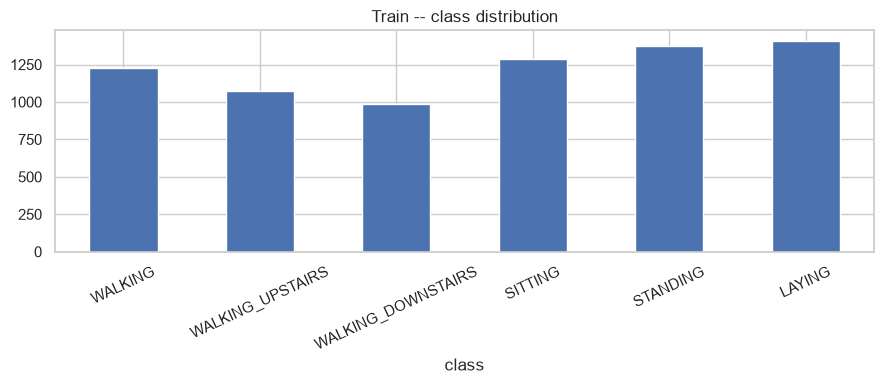

In [2]:
flat = X.transpose(1, 0, 2).reshape(9, -1)
stats = pd.DataFrame({
    "channel": SIGNALS, "sampling_hz": 50 / steps,
    "mean": np.nanmean(flat, axis=1), "median": np.nanmedian(flat, axis=1),
    "std": np.nanstd(flat, axis=1), "min": np.nanmin(flat, axis=1),
    "max": np.nanmax(flat, axis=1), "observed": np.isfinite(flat).sum(axis=1),
    "nan_pct": 100 * np.isnan(flat).mean(axis=1),
    "lost_scheduled_pct": 100 * (1 - np.isfinite(X).sum(axis=(0, 2)) /
                                    (len(X) * scheduled.sum(axis=1))),
})
stats.to_csv(ROOT / "results/01_channel_stats.csv", index=False)
display(stats.round(4))

counts = pd.DataFrame({"class": CLASS_NAMES, "count": np.bincount(y, minlength=6)})
counts.to_csv(ROOT / "results/01_class_counts.csv", index=False)
counts.plot.bar(x="class", y="count", legend=False, figsize=(9, 4))
plt.xticks(rotation=25)
plt.title("Train -- class distribution")
plt.tight_layout()
plt.savefig(ROOT / "figures/01_classes.png", dpi=150)
plt.show()


### Один объект -- реальные моменты измерений

Серая линия -- сигнал после снижения частоты, до отказа.
Точки -- оставшиеся измерения; красная полоса -- непрерывный отказ датчика.
Соединяющую линию через пропуск не рисую.


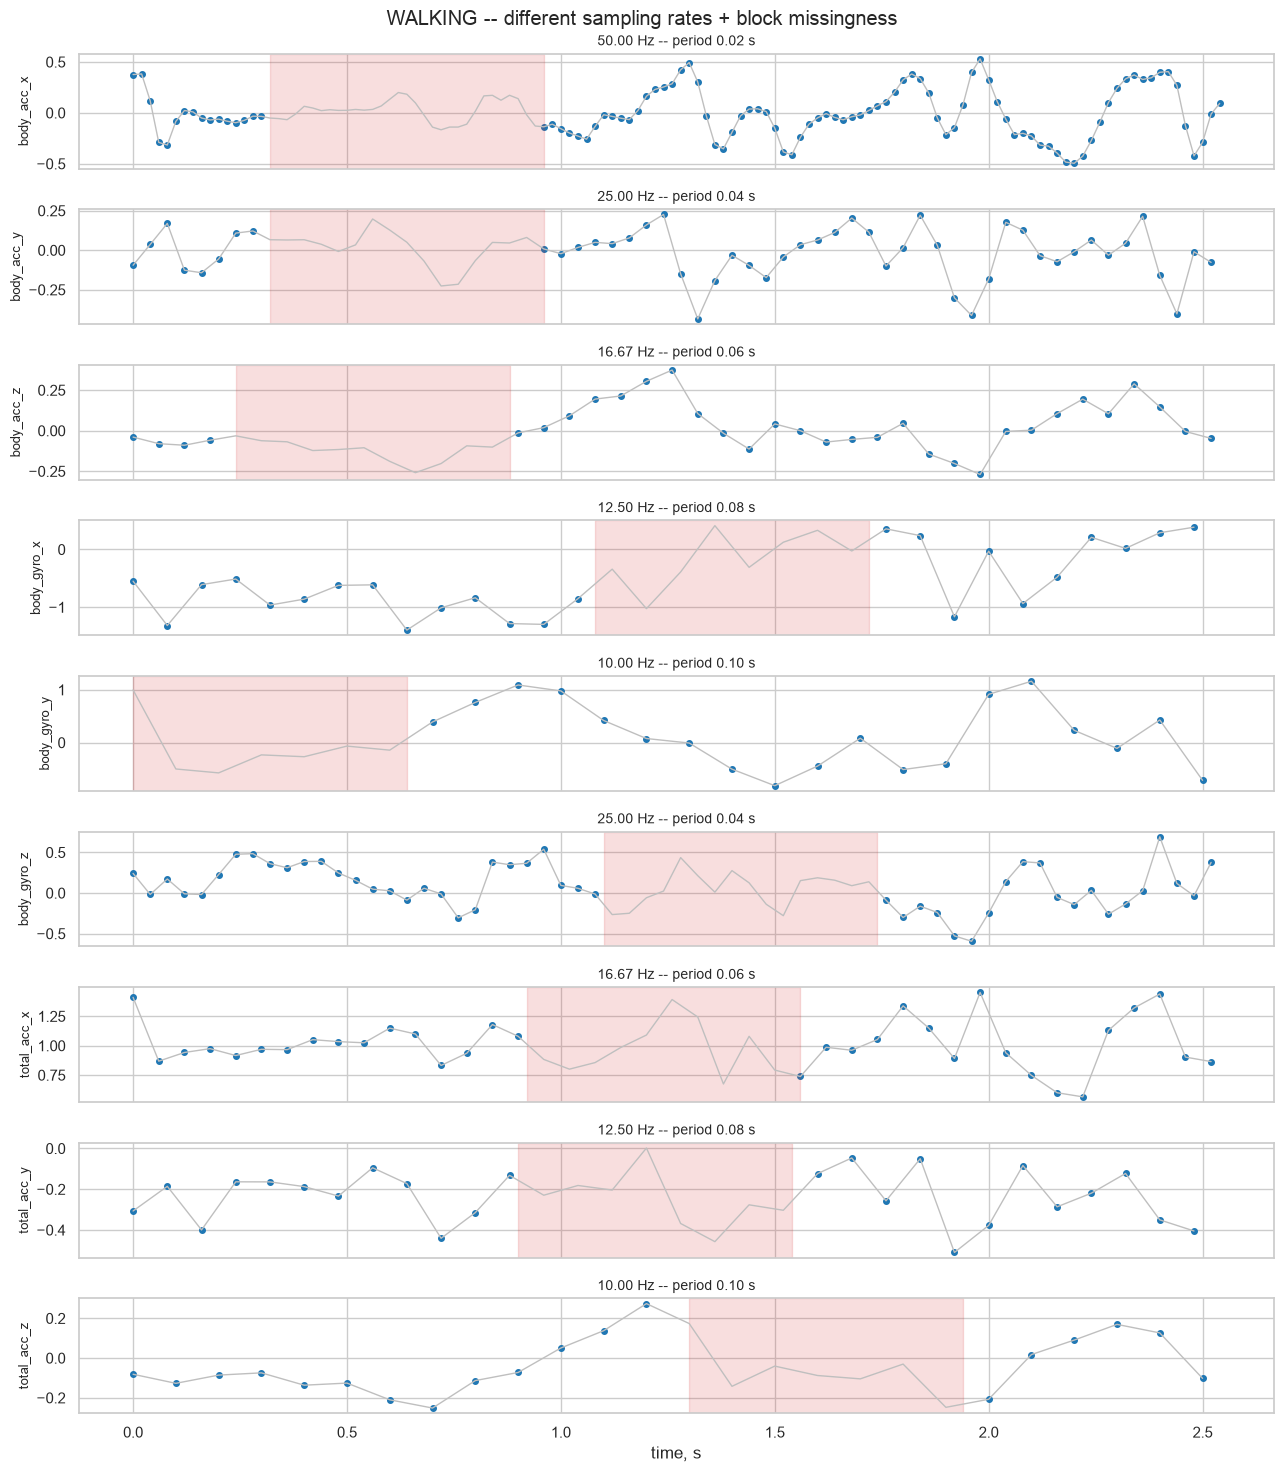

In [3]:
idx = int(np.flatnonzero(y == 0)[0])
fig, axes = plt.subplots(9, 1, figsize=(13, 15), sharex=True)
for c, ax in enumerate(axes):
    points = scheduled[c]
    observed = np.isfinite(X[idx, c])
    ax.plot(t[points], eda["X_train_rates"][idx, c, points], color="0.75", lw=1)
    ax.scatter(t[observed], X[idx, c, observed], s=16, color="tab:blue")
    start = int(data["train_starts"][idx, c, 0]) / 50
    ax.axvspan(start, start + 32 / 50, color="tab:red", alpha=0.15)
    ax.set_ylabel(SIGNALS[c], fontsize=9)
    ax.set_title(f"{50 / steps[c]:.2f} Hz -- period {steps[c] / 50:.2f} s", fontsize=10)
axes[-1].set_xlabel("time, s")
fig.suptitle(f"{CLASS_NAMES[y[idx]]} -- different sampling rates + block missingness")
plt.tight_layout()
plt.savefig(ROOT / "figures/01_observations.png", dpi=150)
plt.show()


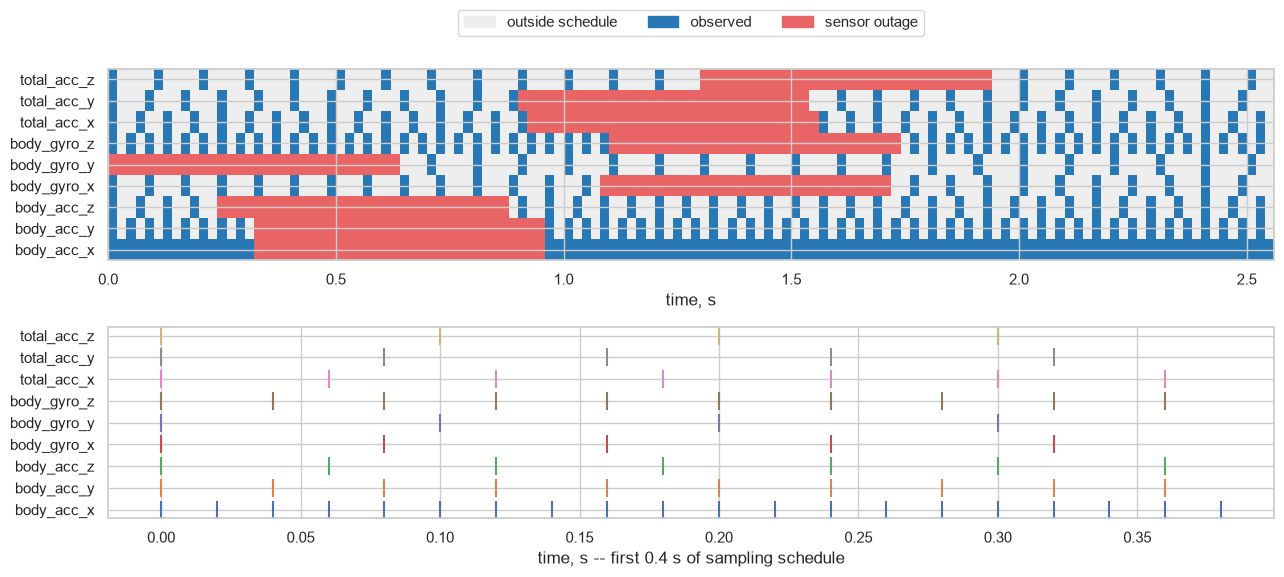

In [4]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# 0 -- нет измерения по расписанию; 1 -- наблюдение; 2 -- отказ.
state = np.broadcast_to(scheduled, (9, 128)).astype(int).copy()
state[eda["train_blocks"][idx]] = 2
fig, axes = plt.subplots(2, 1, figsize=(13, 6))
axes[0].imshow(state, aspect="auto", interpolation="nearest", origin="lower",
               extent=[0, 2.56, -0.5, 8.5], cmap=ListedColormap(["#eeeeee", "#2878b5", "#e96565"]),
               vmin=0, vmax=2)
axes[0].set_yticks(range(9), SIGNALS)
axes[0].set_xlabel("time, s")
axes[0].legend(handles=[Patch(color=c, label=l) for c, l in zip(
    ["#eeeeee", "#2878b5", "#e96565"], ["outside schedule", "observed", "sensor outage"])],
    loc="upper center", bbox_to_anchor=(0.5, 1.35), ncol=3)
for c in range(9):
    points = t[scheduled[c] & (t < 0.4)]
    axes[1].scatter(points, np.full(len(points), c), marker="|", s=160)
axes[1].set_yticks(range(9), SIGNALS)
axes[1].set_xlabel("time, s -- first 0.4 s of sampling schedule")
plt.tight_layout()
plt.savefig(ROOT / "figures/01_masks_rates.png", dpi=150)
plt.show()


### Связи каналов и активность

Корреляции считаю только по совместно наблюдаемым отсчетам.
Рядом сохраняю число таких пар -- у каналов с разными частотами оно различается.
Корреляция описывает связь, но сама по себе не доказывает пользу обмена для модели.


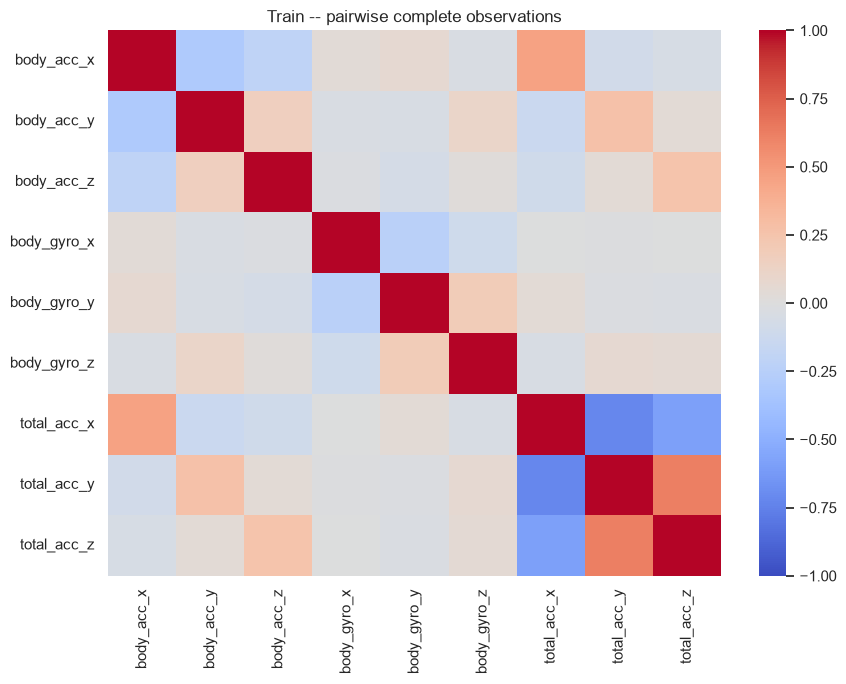

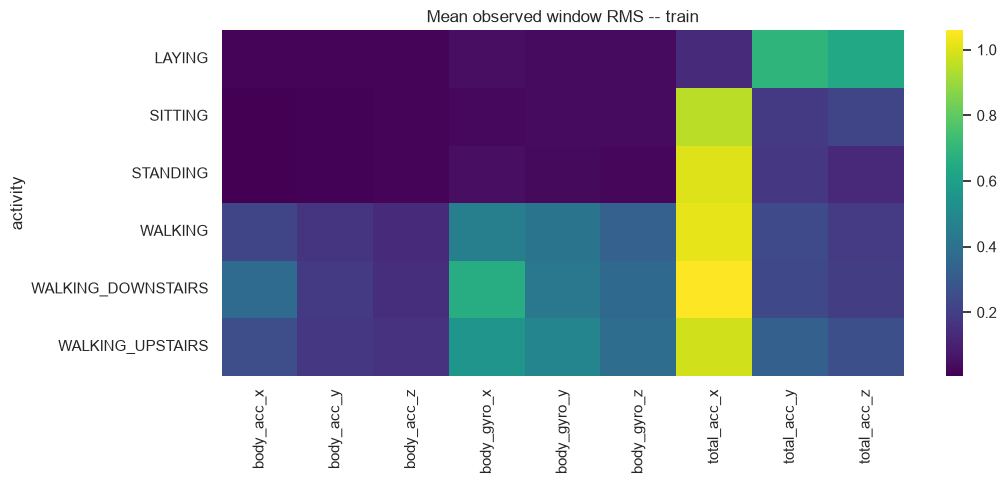

Train windows: 7352
Observed fraction: 0.298
Gap duration: 0.64 s per channel/window
Class count max/min: 1.43


In [5]:
frame = pd.DataFrame(flat.T, columns=SIGNALS)
corr = frame.corr()
valid = np.isfinite(frame.to_numpy()).astype("int64")
pair_counts = pd.DataFrame(valid.T @ valid, index=SIGNALS, columns=SIGNALS)
corr.to_csv(ROOT / "results/01_correlations.csv")
pair_counts.to_csv(ROOT / "results/01_pair_counts.csv")
plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Train -- pairwise complete observations")
plt.tight_layout()
plt.savefig(ROOT / "figures/01_correlations.png", dpi=150)
plt.show()

rms = np.sqrt(np.nanmean(X ** 2, axis=2))
rms_frame = pd.DataFrame(rms, columns=SIGNALS).assign(activity=[CLASS_NAMES[i] for i in y])
rms_by_class = rms_frame.groupby("activity").mean()
rms_by_class.to_csv(ROOT / "results/01_rms.csv")
plt.figure(figsize=(11, 5))
sns.heatmap(rms_by_class, cmap="viridis")
plt.title("Mean observed window RMS -- train")
plt.tight_layout()
plt.savefig(ROOT / "figures/01_rms.png", dpi=150)
plt.show()

print("Train windows:", len(X))
print("Observed fraction:", round(float(np.isfinite(X).mean()), 3))
print("Gap duration:", meta["train_gap_steps"] / 50, "s per channel/window")
print("Class count max/min:", round(float(counts["count"].max() / counts["count"].min()), 2))


### Что беру дальше

Разделяю две причины отсутствия точки: редкое расписание измерений и отказ на интервале.
Ни выбросы, ни неудобные активности автоматически не удаляю.
Для классификации использую macro F1, accuracy и balanced accuracy.
Гипотезу о пользе каналов проверяю обучением и абляцией, а не видом heatmap.
